# Assignment 8: Variational Autoencoder and Latent-Space Visualisation

**Objective:** Build a Variational Autoencoder (VAE) using MNIST data, compare its latent representation with a normal autoencoder, and study how generated digits change across different latent-space locations.

## Step 1: Import the required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Step 2: Prepare the MNIST data

In [2]:
# Convert each image to a tensor with pixel values between 0 and 1
to_tensor = transforms.ToTensor()

train_set = datasets.MNIST(
    root="mnist_data",
    train=True,
    download=True,
    transform=to_tensor
)

test_set = datasets.MNIST(
    root="mnist_data",
    train=False,
    download=True,
    transform=to_tensor
)

train_loader = torch.utils.data.DataLoader(
    train_set,
    batch_size=128,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_set,
    batch_size=128,
    shuffle=False
)

print("Number of training images:", len(train_set))
print("Number of test images:", len(test_set))

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.55MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.10MB/s]

Number of training images: 60000
Number of test images: 10000


## Step 3: View a few original MNIST images

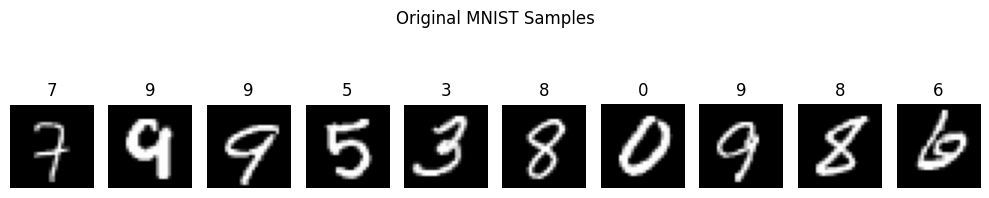

In [3]:
sample_images, sample_labels = next(iter(train_loader))

plt.figure(figsize=(10, 2.5))

for idx in range(10):
    plt.subplot(1, 10, idx + 1)
    plt.imshow(sample_images[idx].squeeze(), cmap="gray")
    plt.title(int(sample_labels[idx]))
    plt.axis("off")

plt.suptitle("Original MNIST Samples")
plt.tight_layout()
plt.show()

## Step 4: Build a basic Autoencoder

The normal autoencoder first compresses a 28×28 image into a two-dimensional latent vector. The decoder then expands that vector back into a 784-pixel image. Since MNIST pixels are between 0 and 1, a sigmoid activation is used at the decoder output.

In [4]:
class BasicAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, images):
        flat = images.reshape(-1, 784)
        latent_code = self.encoder(flat)
        reconstruction = self.decoder(latent_code)
        return reconstruction, latent_code


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ae_model = BasicAutoencoder().to(device)
print(ae_model)

BasicAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## Step 5: Train the normal Autoencoder

In [5]:
ae_loss = nn.BCELoss()
ae_optimizer = optim.Adam(ae_model.parameters(), lr=0.001)

for epoch in range(15):
    running_loss = 0.0

    for batch_images, _ in train_loader:
        batch_images = batch_images.to(device)

        reconstructed, _ = ae_model(batch_images)
        original_flat = batch_images.reshape(-1, 784)

        loss = ae_loss(reconstructed, original_flat)

        ae_optimizer.zero_grad()
        loss.backward()
        ae_optimizer.step()

        running_loss += loss.item()

    mean_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch + 1:02d}/15 | Loss: {mean_loss:.4f}")

Epoch 01/15 | Loss: 0.2445
Epoch 02/15 | Loss: 0.2037
Epoch 03/15 | Loss: 0.1938
Epoch 04/15 | Loss: 0.1889
Epoch 05/15 | Loss: 0.1857
Epoch 06/15 | Loss: 0.1833
Epoch 07/15 | Loss: 0.1818
Epoch 08/15 | Loss: 0.1800
Epoch 09/15 | Loss: 0.1791
Epoch 10/15 | Loss: 0.1779
Epoch 11/15 | Loss: 0.1769
Epoch 12/15 | Loss: 0.1760
Epoch 13/15 | Loss: 0.1753
Epoch 14/15 | Loss: 0.1745
Epoch 15/15 | Loss: 0.1740


## Step 6: Visualise the normal Autoencoder latent space

The encoder is used on the test set and its two latent values are plotted. The colour of each point represents the corresponding digit.

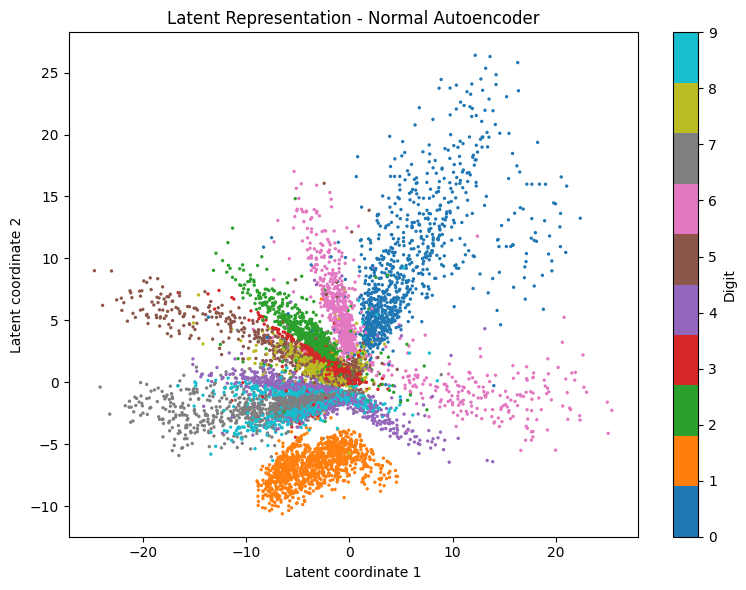

In [6]:
ae_model.eval()

ae_points = []
ae_digit_labels = []

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)
        _, codes = ae_model(batch_images)

        ae_points.append(codes.cpu().numpy())
        ae_digit_labels.append(batch_labels.numpy())

ae_points = np.concatenate(ae_points)
ae_digit_labels = np.concatenate(ae_digit_labels)

plt.figure(figsize=(8, 6))
plot = plt.scatter(
    ae_points[:, 0],
    ae_points[:, 1],
    c=ae_digit_labels,
    cmap="tab10",
    s=2
)

plt.colorbar(plot, label="Digit")
plt.xlabel("Latent coordinate 1")
plt.ylabel("Latent coordinate 2")
plt.title("Latent Representation - Normal Autoencoder")
plt.tight_layout()
plt.show()

## Step 7: Create the Variational Autoencoder

A VAE does not directly produce one fixed latent point. Its encoder predicts a mean and log-variance for each input. A latent sample is then obtained using the reparameterisation trick before it is passed to the decoder.

In [7]:
class VariationalAutoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.feature_extractor = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU()
        )

        self.mean_layer = nn.Linear(64, 2)
        self.logvar_layer = nn.Linear(64, 2)

        self.decoder = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def sample_latent(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        random_part = torch.randn_like(std)
        return mean + random_part * std

    def forward(self, images):
        flat_images = images.reshape(-1, 784)

        hidden = self.feature_extractor(flat_images)
        mean = self.mean_layer(hidden)
        logvar = self.logvar_layer(hidden)

        z = self.sample_latent(mean, logvar)
        reconstructed = self.decoder(z)

        return reconstructed, mean, logvar


vae_model = VariationalAutoencoder().to(device)
print(vae_model)

VariationalAutoencoder(
  (feature_extractor): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=64, bias=True)
    (3): ReLU()
  )
  (mean_layer): Linear(in_features=64, out_features=2, bias=True)
  (logvar_layer): Linear(in_features=64, out_features=2, bias=True)
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)


## Step 8: Define the VAE loss

The VAE objective combines two parts:

- **Reconstruction loss:** checks how close the generated image is to the input.
- **KL divergence:** encourages the latent distribution to remain close to a standard normal distribution.

The two terms together produce the final training loss.

In [8]:
def calculate_vae_loss(reconstructed, original, mean, logvar):
    original = original.reshape(-1, 784)

    reconstruction = nn.functional.mse_loss(
        reconstructed,
        original,
        reduction="sum"
    )

    kl = -0.5 * torch.sum(
        1 + logvar - mean.pow(2) - logvar.exp()
    )

    combined = reconstruction + kl

    return combined, reconstruction, kl


print("VAE loss function is ready.")

VAE loss function is ready.


## Step 9: Train the VAE for 20 epochs

In [9]:
vae_optimizer = optim.Adam(vae_model.parameters(), lr=0.001)

history_total = []
history_reconstruction = []
history_kl = []

for epoch in range(20):
    epoch_total = 0.0
    epoch_reconstruction = 0.0
    epoch_kl = 0.0

    for batch_images, _ in train_loader:
        batch_images = batch_images.to(device)

        output, mean, logvar = vae_model(batch_images)

        total, reconstruction, kl = calculate_vae_loss(
            output,
            batch_images,
            mean,
            logvar
        )

        vae_optimizer.zero_grad()
        total.backward()
        vae_optimizer.step()

        epoch_total += total.item()
        epoch_reconstruction += reconstruction.item()
        epoch_kl += kl.item()

    mean_total = epoch_total / len(train_loader)
    mean_reconstruction = epoch_reconstruction / len(train_loader)
    mean_kl = epoch_kl / len(train_loader)

    history_total.append(mean_total)
    history_reconstruction.append(mean_reconstruction)
    history_kl.append(mean_kl)

    print(
        f"Epoch {epoch + 1:02d}/20 | "
        f"Total: {mean_total:.2f} | "
        f"Reconstruction: {mean_reconstruction:.2f} | "
        f"KL: {mean_kl:.2f}"
    )

Epoch 01/20 | Total: 6613.62 | Reconstruction: 6385.86 | KL: 227.76
Epoch 02/20 | Total: 5478.75 | Reconstruction: 5071.51 | KL: 407.24
Epoch 03/20 | Total: 5252.96 | Reconstruction: 4793.97 | KL: 458.99
Epoch 04/20 | Total: 5115.63 | Reconstruction: 4623.63 | KL: 492.00
Epoch 05/20 | Total: 5014.64 | Reconstruction: 4494.28 | KL: 520.36
Epoch 06/20 | Total: 4935.36 | Reconstruction: 4392.84 | KL: 542.52
Epoch 07/20 | Total: 4868.84 | Reconstruction: 4311.92 | KL: 556.92
Epoch 08/20 | Total: 4816.98 | Reconstruction: 4246.46 | KL: 570.52
Epoch 09/20 | Total: 4774.64 | Reconstruction: 4193.83 | KL: 580.82
Epoch 10/20 | Total: 4739.56 | Reconstruction: 4147.82 | KL: 591.74
Epoch 11/20 | Total: 4709.83 | Reconstruction: 4110.73 | KL: 599.10
Epoch 12/20 | Total: 4680.16 | Reconstruction: 4074.36 | KL: 605.80
Epoch 13/20 | Total: 4655.34 | Reconstruction: 4041.67 | KL: 613.67
Epoch 14/20 | Total: 4633.86 | Reconstruction: 4017.03 | KL: 616.83
Epoch 15/20 | Total: 4612.77 | Reconstruction: 3

## Step 10: Plot the VAE training losses

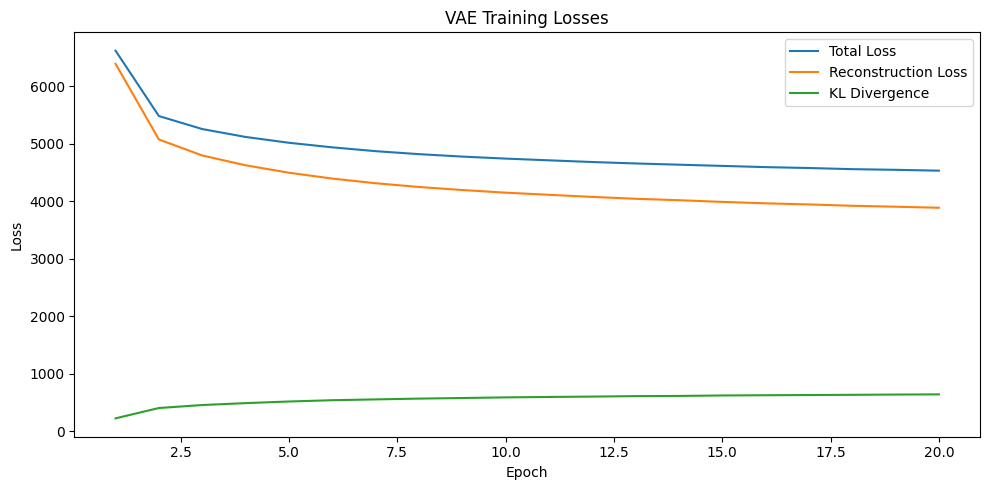

In [10]:
epoch_numbers = range(1, 21)

plt.figure(figsize=(10, 5))
plt.plot(epoch_numbers, history_total, label="Total Loss")
plt.plot(epoch_numbers, history_reconstruction, label="Reconstruction Loss")
plt.plot(epoch_numbers, history_kl, label="KL Divergence")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Training Losses")
plt.legend()
plt.tight_layout()
plt.show()

## Step 11: Compare original and reconstructed images

The following cell takes test images and passes them through the trained VAE. The original images are shown above their corresponding reconstructions.

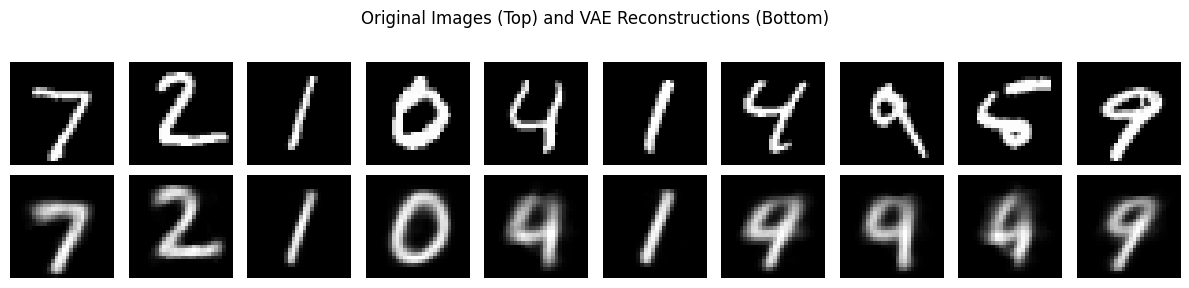

In [11]:
vae_model.eval()

test_batch, _ = next(iter(test_loader))
test_batch_device = test_batch.to(device)

with torch.no_grad():
    rebuilt, _, _ = vae_model(test_batch_device)

rebuilt = rebuilt.reshape(-1, 28, 28).cpu().numpy()
original = test_batch.squeeze().numpy()

plt.figure(figsize=(12, 3))

for idx in range(10):
    plt.subplot(2, 10, idx + 1)
    plt.imshow(original[idx], cmap="gray")
    plt.axis("off")

    plt.subplot(2, 10, idx + 11)
    plt.imshow(rebuilt[idx], cmap="gray")
    plt.axis("off")

plt.suptitle("Original Images (Top) and VAE Reconstructions (Bottom)")
plt.tight_layout()
plt.show()

## Step 12: Plot the VAE latent representation

For the VAE, the mean vector is used as the representative latent coordinate for each test image.

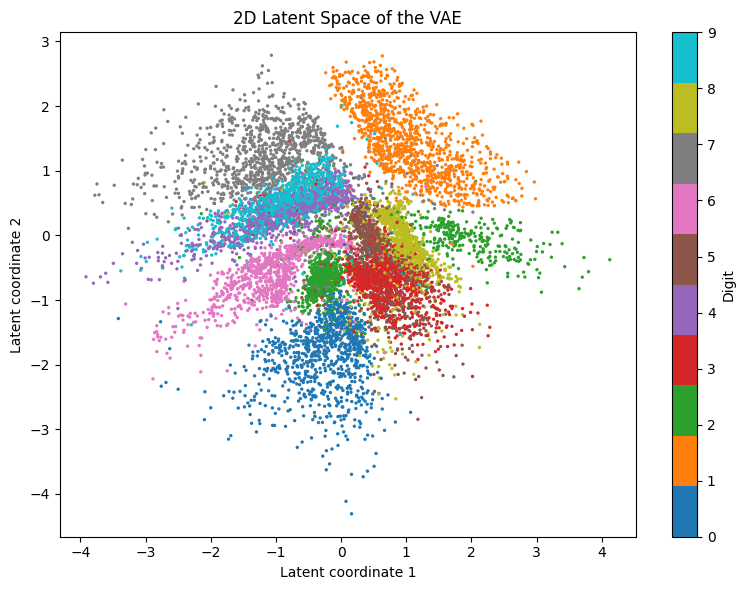

In [12]:
vae_model.eval()

latent_points = []
latent_labels = []

with torch.no_grad():
    for batch_images, batch_labels in test_loader:
        batch_images = batch_images.to(device)

        _, mean, _ = vae_model(batch_images)

        latent_points.append(mean.cpu().numpy())
        latent_labels.append(batch_labels.numpy())

latent_points = np.concatenate(latent_points)
latent_labels = np.concatenate(latent_labels)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    latent_points[:, 0],
    latent_points[:, 1],
    c=latent_labels,
    cmap="tab10",
    s=2
)

plt.colorbar(scatter, label="Digit")
plt.xlabel("Latent coordinate 1")
plt.ylabel("Latent coordinate 2")
plt.title("2D Latent Space of the VAE")
plt.tight_layout()
plt.show()

## Step 13: Generate digits across the latent space

A regular grid of latent points is created between -3 and +3. Each point is sent directly through the decoder so that the change in generated digits can be observed.

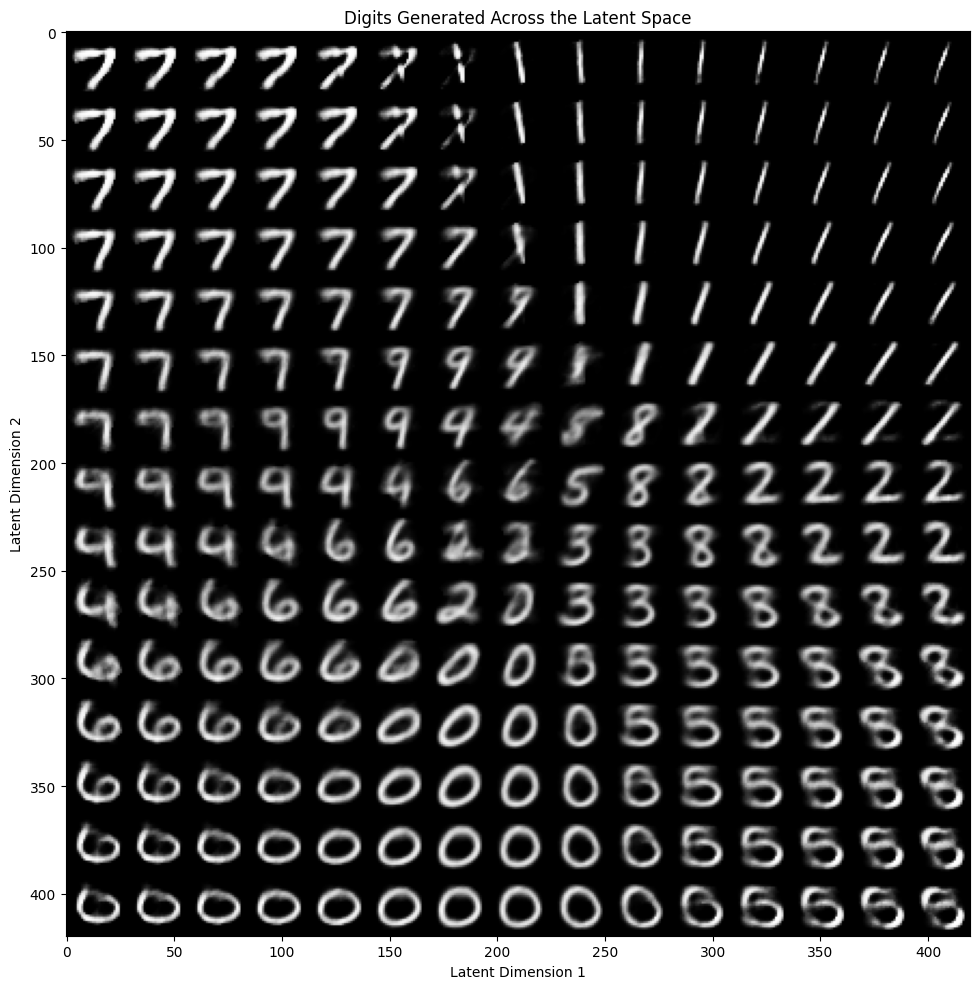

In [13]:
vae_model.eval()

grid_size = 15
latent_limit = 3.0

x_values = np.linspace(-latent_limit, latent_limit, grid_size)
y_values = np.linspace(-latent_limit, latent_limit, grid_size)

canvas = np.zeros((28 * grid_size, 28 * grid_size))

with torch.no_grad():
    for row, y_value in enumerate(y_values[::-1]):
        for col, x_value in enumerate(x_values):
            latent_vector = torch.tensor(
                [[x_value, y_value]],
                dtype=torch.float32,
                device=device
            )

            generated = vae_model.decoder(latent_vector)
            digit_image = generated.cpu().numpy().reshape(28, 28)

            canvas[
                row * 28:(row + 1) * 28,
                col * 28:(col + 1) * 28
            ] = digit_image

plt.figure(figsize=(10, 10))
plt.imshow(canvas, cmap="gray")
plt.title("Digits Generated Across the Latent Space")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.tight_layout()
plt.show()

## Step 14: Test points near the edges of the latent space

Several points outside the main -3 to +3 grid are decoded to observe how the model behaves near the boundaries.

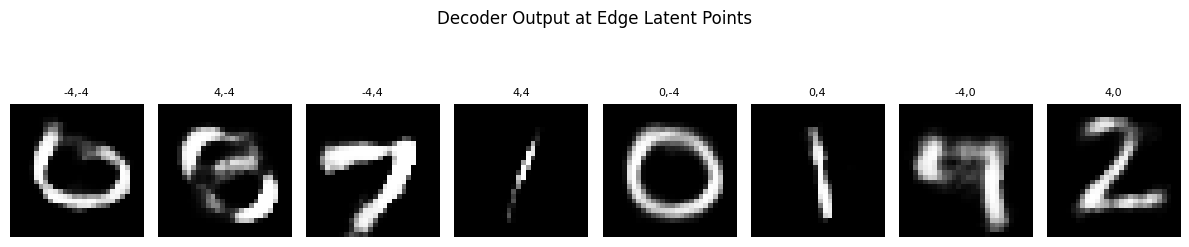

In [14]:
edge_locations = [
    (-4, -4), (4, -4),
    (-4, 4), (4, 4),
    (0, -4), (0, 4),
    (-4, 0), (4, 0)
]

plt.figure(figsize=(12, 3))

with torch.no_grad():
    for position, (x_value, y_value) in enumerate(edge_locations):
        z = torch.tensor(
            [[x_value, y_value]],
            dtype=torch.float32,
            device=device
        )

        result = vae_model.decoder(z)
        image = result.cpu().numpy().reshape(28, 28)

        plt.subplot(1, 8, position + 1)
        plt.imshow(image, cmap="gray")
        plt.title(f"{x_value},{y_value}", fontsize=8)
        plt.axis("off")

plt.suptitle("Decoder Output at Edge Latent Points")
plt.tight_layout()
plt.show()

## Step 15: Try a point far outside the learned latent region

The decoder is also tested with a much larger latent coordinate to see what happens when the input is far away from the region learned during training.

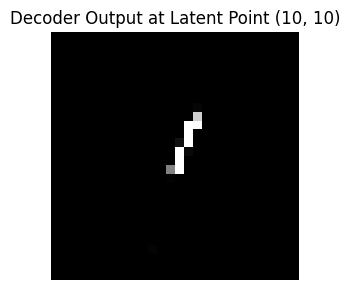

Minimum pixel value: 0.0000
Maximum pixel value: 1.0000
Average pixel value: 0.0108


In [15]:
far_point = torch.tensor(
    [[10.0, 10.0]],
    dtype=torch.float32,
    device=device
)

with torch.no_grad():
    far_output = vae_model.decoder(far_point)

far_image = far_output.cpu().numpy().reshape(28, 28)

plt.figure(figsize=(3, 3))
plt.imshow(far_image, cmap="gray")
plt.title("Decoder Output at Latent Point (10, 10)")
plt.axis("off")
plt.tight_layout()
plt.show()

print(f"Minimum pixel value: {far_image.min():.4f}")
print(f"Maximum pixel value: {far_image.max():.4f}")
print(f"Average pixel value: {far_image.mean():.4f}")

## Written Observations

### 1. Do similar digits form clusters?

The VAE latent-space plot shows that several digits occupy their own regions. The groups are more structured around the centre of the latent space than those produced by the normal autoencoder. Some visually related digits still appear close to one another.

### 2. Are the clusters completely separated?

No. There is some overlap between groups, particularly for digits with similar shapes. Even so, the VAE representation is more organised because the KL-divergence term encourages the latent variables to follow a regular distribution.

### 3. What happens when moving through the latent space?

The generated digits change gradually as the latent coordinates are changed. Instead of producing unrelated images at neighbouring points, the decoder often creates intermediate shapes between different digit types.

### 4. Are the transitions smooth?

The latent-space grid generally shows smooth transitions. This is an important characteristic of a VAE because its regularised latent space allows nearby points to produce related outputs.

### 5. What happens at extreme points?

The images produced around the outer edge of the tested latent region can become distorted because those areas contain less information learned from the training data. A point such as (10, 10), which is much farther from the main latent region, can produce an unclear or meaningless pattern rather than a recognisable digit.

**Note:** The exact appearance of the plots and generated images depends on the model's training run.